In [1]:
!pip install yfinance


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc

import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, r2_score
from collections import defaultdict

%matplotlib inline

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

Colour_Palette = ['#01BEFE', '#FF7D00', '#FFDD00', '#FF006D', '#ADFF02', '#8F00FF']
sns.set_palette(sns.color_palette(Colour_Palette))

tqdm.pandas()


In [3]:
import yfinance as yf
from datetime import date

end_date = date.today().strftime("%Y-%m-%d")
start_date = '1990-01-01'

df = yf.download('AAPL', start=start_date, end=end_date)

# Inspect the data
print(df.head())
print(df.info())


[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          AAPL      AAPL      AAPL      AAPL       AAPL
Date                                                         
1990-01-02  0.260705  0.262455  0.244958  0.246708  183198400
1990-01-03  0.262455  0.265955  0.262455  0.265955  207995200
1990-01-04  0.263330  0.271203  0.260705  0.267704  221513600
1990-01-05  0.264205  0.267704  0.258956  0.264205  123312000
1990-01-08  0.265955  0.265955  0.258956  0.262455  101572800
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9134 entries, 1990-01-02 to 2026-04-09
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   9134 non-null   float64
 1   (High, AAPL)    9134 non-null   float64
 2   (Low, AAPL)     9134 non-null   float64
 3   (Open, AAPL)    9134 non-null   float64
 4   (Volume, AAPL)  9134 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 428.2 KB
None


In [4]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
1990-01-02,0.260705,0.262455,0.244958,0.246708,183198400
1990-01-03,0.262455,0.265955,0.262455,0.265955,207995200
1990-01-04,0.263330,0.271203,0.260705,0.267704,221513600
1990-01-05,0.264205,0.267704,0.258956,0.264205,123312000
1990-01-08,0.265955,0.265955,0.258956,0.262455,101572800


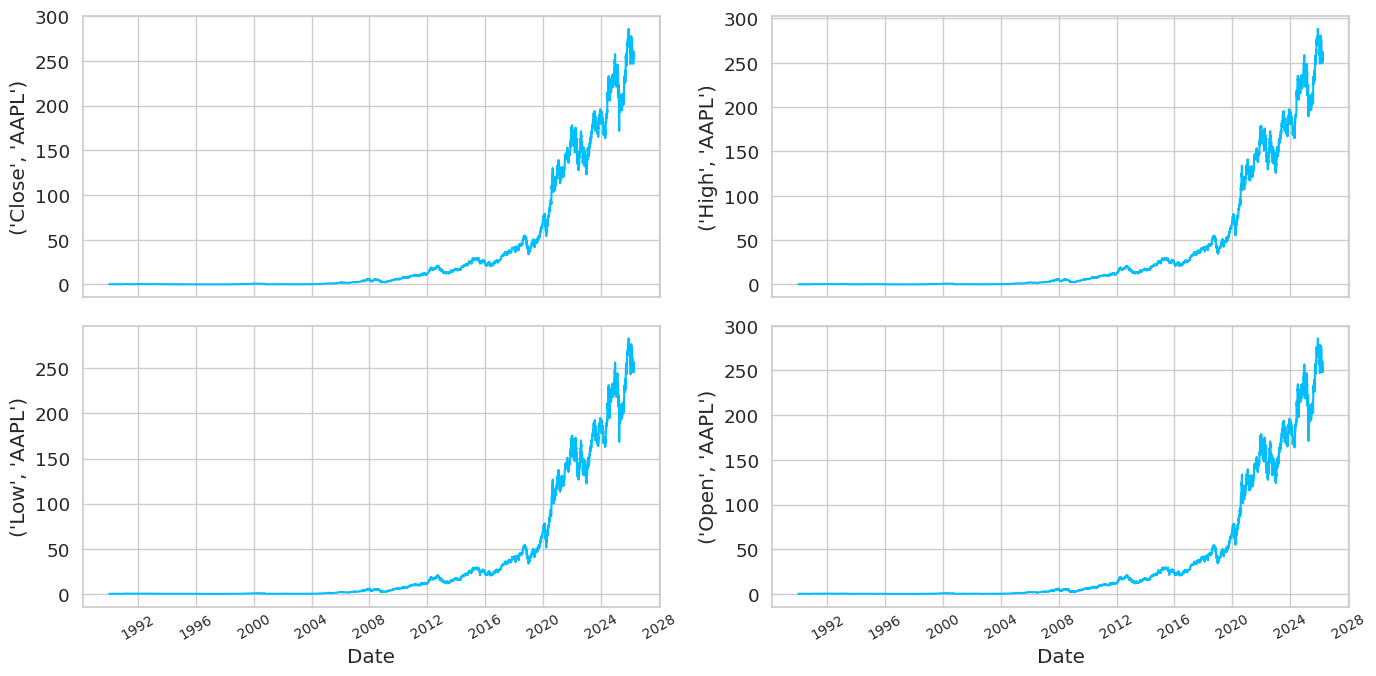

In [5]:
import matplotlib.dates as mdates

def data_plot(df):
    # Plot line charts
    df_plot = df.copy()

    ncols = 2
    nrows = int(round(df_plot.shape[1] / ncols, 0))

    fig, ax = plt.subplots(nrows=nrows, ncols=ncols, sharex=True, figsize=(14, 7))
    for i, ax in enumerate(fig.axes):
        sns.lineplot(data=df_plot.iloc[:, i], ax=ax)
        ax.tick_params(axis="x", rotation=30, labelsize=10, length=0)
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.tight_layout()
    plt.show()

# Plot the data
data_plot(df)


In [7]:
import math
from sklearn.preprocessing import MinMaxScaler

# Train test split
training_data_len = math.ceil(len(df) * .8)
print(training_data_len)

# Splitting the dataset
train_data = df[:training_data_len].iloc[:, :4]
test_data = df[training_data_len:].iloc[:, :4]
print(train_data.shape, test_data.shape)

# Selecting Open Price values
dataset_train = train_data.Open.values
# Reshaping 1D to 2D array
dataset_train = np.reshape(dataset_train, (-1, 1))
print(dataset_train.shape)

# Selecting Open Price values
dataset_test = test_data.Open.values
# Reshaping 1D to 2D array
dataset_test = np.reshape(dataset_test, (-1, 1))
print(dataset_test.shape)

scaler = MinMaxScaler(feature_range=(0, 1))
# Scaling dataset
scaled_train = scaler.fit_transform(dataset_train)
print(scaled_train[:5])

# Normalizing values between 0 and 1
scaled_test = scaler.fit_transform(dataset_test)
print(scaled_test[:5])


7308
(7308, 4) (1826, 4)
(7308, 1)
(1826, 1)
[[0.00275614]
 [0.00310917]
 [0.00314126]
 [0.00307708]
 [0.00304498]]
[[0.        ]
 [0.00051886]
 [0.00445274]
 [0.00526401]
 [0.0068961 ]]


In [8]:
# Create sequences and labels for training data
sequence_length = 50  # Number of time steps to look back
X_train, y_train = [], []
for i in range(len(scaled_train) - sequence_length):
    X_train.append(scaled_train[i:i + sequence_length])
    y_train.append(scaled_train[i + sequence_length])  # Predicting the value right after the sequence
X_train, y_train = np.array(X_train), np.array(y_train)

# Convert data to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
print(X_train.shape, y_train.shape)

# Create sequences and labels for testing data
sequence_length = 30  # Number of time steps to look back
X_test, y_test = [], []
for i in range(len(scaled_test) - sequence_length):
    X_test.append(scaled_test[i:i + sequence_length])
    y_test.append(scaled_test[i + sequence_length])  # Predicting the value right after the sequence
X_test, y_test = np.array(X_test), np.array(y_test)

# Convert data to PyTorch tensors
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
print(X_test.shape, y_test.shape)


torch.Size([7258, 50, 1]) torch.Size([7258, 1])
torch.Size([1796, 30, 1]) torch.Size([1796, 1])


In [9]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])
        return out

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

input_size = 1
num_layers = 3  # Increased number of layers
hidden_size = 128  # Increased number of hidden units
output_size = 1
dropout = 0.2  # Added dropout for regularization

model = LSTMModel(input_size, hidden_size, num_layers, dropout).to(device)
loss_fn = nn.MSELoss(reduction='mean')
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # Learning rate

batch_size = 32  # Adjusted batch size
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

num_epochs = 100  # Increased number of epochs
train_hist = []
test_hist = []

for epoch in range(num_epochs):
    total_loss = 0.0
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        predictions = model(batch_X)
        loss = loss_fn(predictions, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)
    train_hist.append(average_loss)

    model.eval()
    with torch.no_grad():
        total_test_loss = 0.0

        for batch_X_test, batch_y_test in test_loader:
            batch_X_test, batch_y_test = batch_X_test.to(device), batch_y_test.to(device)
            predictions_test = model(batch_X_test)
            test_loss = loss_fn(predictions_test, batch_y_test)

            total_test_loss += test_loss.item()

        average_test_loss = total_test_loss / len(test_loader)
        test_hist.append(average_test_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}] - Training Loss: {average_loss:.4f}, Test Loss: {average_test_loss:.4f}')


cuda
Epoch [10/100] - Training Loss: 0.0002, Test Loss: 0.0005
Epoch [20/100] - Training Loss: 0.0001, Test Loss: 0.0003
Epoch [30/100] - Training Loss: 0.0001, Test Loss: 0.0005
Epoch [40/100] - Training Loss: 0.0001, Test Loss: 0.0003
Epoch [50/100] - Training Loss: 0.0001, Test Loss: 0.0008
Epoch [60/100] - Training Loss: 0.0001, Test Loss: 0.0002
Epoch [70/100] - Training Loss: 0.0001, Test Loss: 0.0002
Epoch [80/100] - Training Loss: 0.0001, Test Loss: 0.0002
Epoch [90/100] - Training Loss: 0.0001, Test Loss: 0.0003
Epoch [100/100] - Training Loss: 0.0001, Test Loss: 0.0002


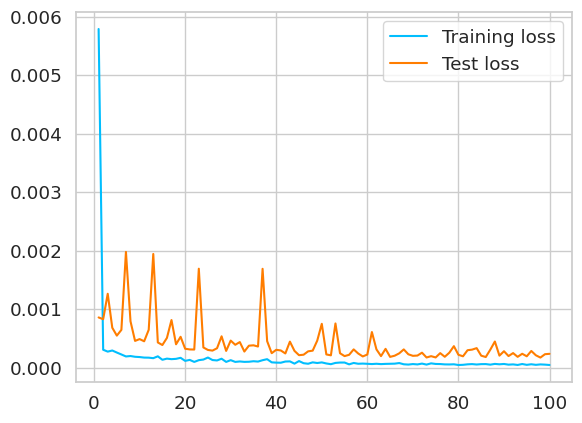

In [10]:
x = np.linspace(1,num_epochs,num_epochs)
plt.plot(x,train_hist,scalex=True, label="Training loss")
plt.plot(x, test_hist, label="Test loss")
plt.legend()
plt.show()


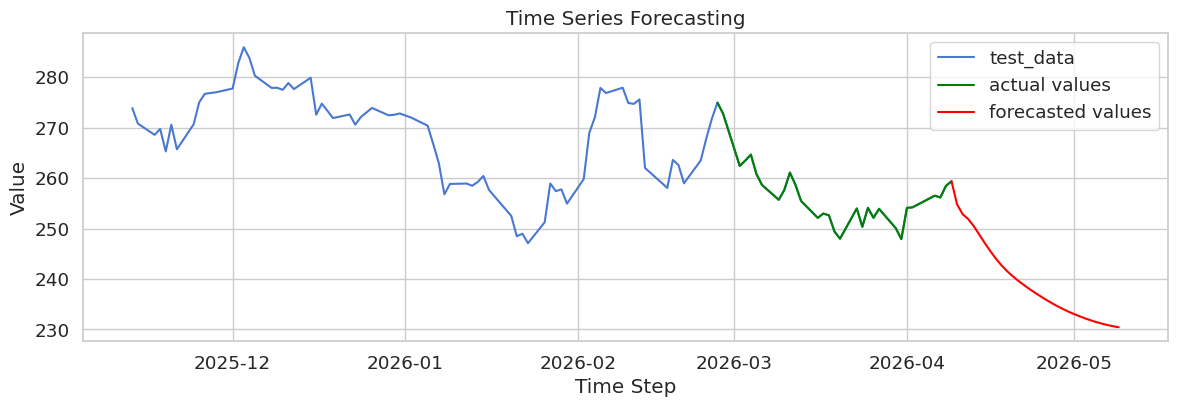

RMSE: 0.0154
R² Score: 0.9961


In [14]:
num_forecast_steps = 30
sequence_to_plot = X_test.squeeze().cpu().numpy()
historical_data = sequence_to_plot[-1]

forecasted_values = []
with torch.no_grad():
    for _ in range(num_forecast_steps):
        historical_data_tensor = torch.as_tensor(historical_data).view(1, -1, 1).float().to(device)
        predicted_value = model(historical_data_tensor).cpu().numpy()[0, 0]
        forecasted_values.append(predicted_value)
        historical_data = np.roll(historical_data, shift=-1)
        historical_data[-1] = predicted_value

last_date = test_data.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(1), periods=30)

# yfinance may return 'Open' as a DataFrame (2D) when columns are MultiIndex.
# Convert it to 1D to keep plotting/concatenation dimensions consistent.
open_values = np.asarray(test_data.Open).reshape(-1)
forecast_values = scaler.inverse_transform(np.array(forecasted_values).reshape(-1, 1)).reshape(-1)

plt.rcParams['figure.figsize'] = [14, 4]
plt.plot(test_data.index[-100:], open_values[-100:], label="test_data", color="b")
plt.plot(test_data.index[-30:], open_values[-30:], label='actual values', color='green')
plt.plot(
    test_data.index[-1:].append(future_dates),
    np.concatenate([open_values[-1:], forecast_values]),
    label='forecasted values',
    color='red'
 )

plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.title('Time Series Forecasting')
plt.grid(True)
plt.show()

# Evaluate the model and calculate RMSE and R² score
model.eval()
with torch.no_grad():
    test_predictions = []
    for batch_X_test in X_test:
        batch_X_test = batch_X_test.to(device).unsqueeze(0)  # Add batch dimension
        test_predictions.append(model(batch_X_test).cpu().numpy().flatten()[0])

test_predictions = np.array(test_predictions)
y_true = y_test.cpu().numpy().reshape(-1)

# Calculate RMSE and R² score
rmse = np.sqrt(mean_squared_error(y_true, test_predictions))
r2 = r2_score(y_true, test_predictions)

print(f'RMSE: {rmse:.4f}')
print(f'R² Score: {r2:.4f}')

,Historical_Open,Forecast_Open
2025-11-13,273.853744,NaN
2025-11-14,270.796590,NaN
2025-11-17,268.568705,NaN
2025-11-18,269.737607,NaN
2025-11-19,265.281763,NaN
...,...,...
2026-05-05,NaN,231.452026
2026-05-06,NaN,231.144470
2026-05-07,NaN,230.865387
2026-05-08,NaN,230.631210


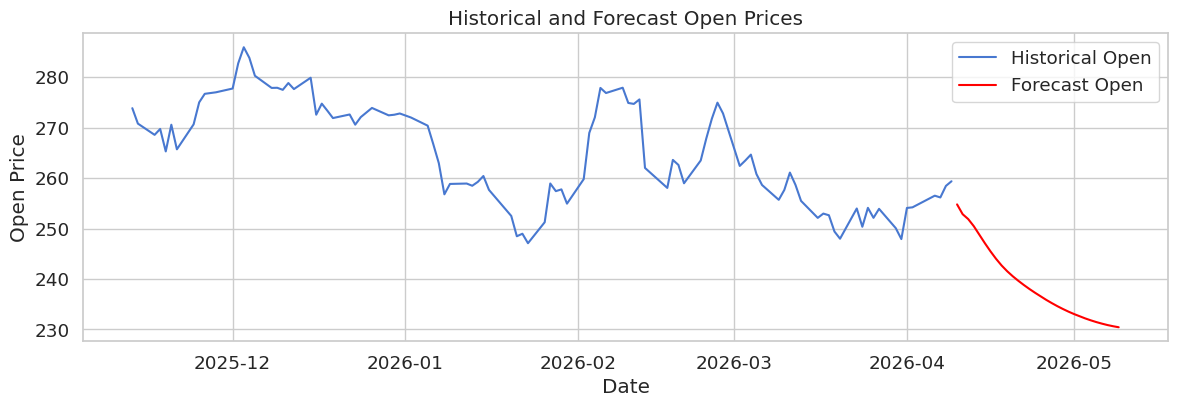

In [15]:
# Display historical and forecast data together (same time window as the previous cell)
history_window = 100
forecast_window = 30

# Ensure Open values are 1D even if yfinance returns a 2D DataFrame column.
open_series = pd.Series(np.asarray(test_data.Open).reshape(-1), index=test_data.index, name="Historical_Open")
historical_series = open_series[-history_window:]
forecast_series = pd.Series(
    scaler.inverse_transform(np.array(forecasted_values).reshape(-1, 1)).reshape(-1),
    index=future_dates[:forecast_window],
    name="Forecast_Open"
 )

combined_index = historical_series.index.append(forecast_series.index)
combined_df = pd.DataFrame(index=combined_index)
combined_df["Historical_Open"] = np.nan
combined_df["Forecast_Open"] = np.nan
combined_df.loc[historical_series.index, "Historical_Open"] = historical_series.values
combined_df.loc[forecast_series.index, "Forecast_Open"] = forecast_series.values

display(combined_df)

plt.figure(figsize=(14, 4))
plt.plot(combined_df.index, combined_df["Historical_Open"], label="Historical Open", color="b")
plt.plot(combined_df.index, combined_df["Forecast_Open"], label="Forecast Open", color="red")
plt.title("Historical and Forecast Open Prices")
plt.xlabel("Date")
plt.ylabel("Open Price")
plt.grid(True)
plt.legend()
plt.show()

Real vs Predict on test period (last 30 days):


,Real_Value,Predict_Value,Error,Abs_Error
Date,,,,
2026-02-26,274.950012,266.344055,-8.605957,8.605957
2026-02-27,272.809998,269.768311,-3.041687,3.041687
2026-03-02,262.410004,270.147888,7.737885,7.737885
2026-03-03,263.480011,265.433105,1.953094,1.953094
2026-03-04,264.649994,265.664978,1.014984,1.014984
2026-03-05,260.790039,263.432007,2.641968,2.641968
2026-03-06,258.630005,259.661163,1.031158,1.031158
2026-03-09,255.690002,257.446625,1.756622,1.756622
2026-03-10,257.649994,254.382843,-3.267151,3.267151


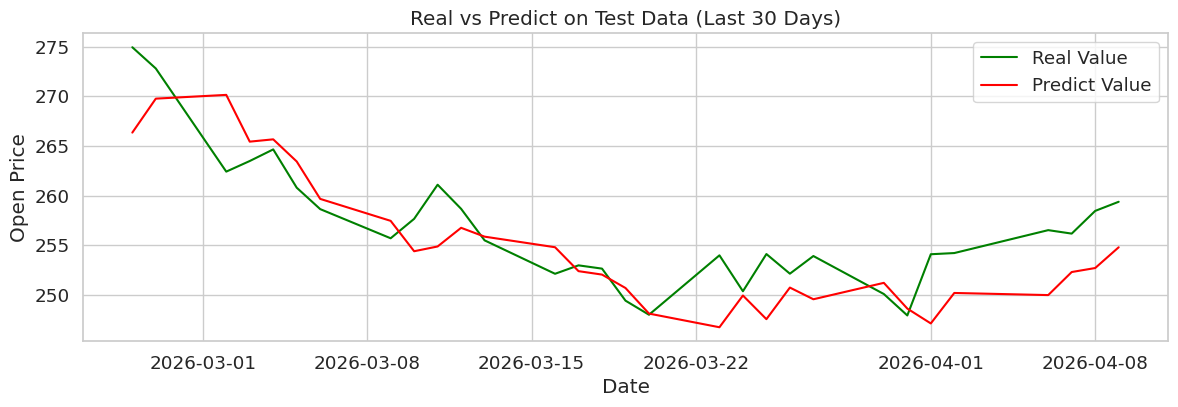

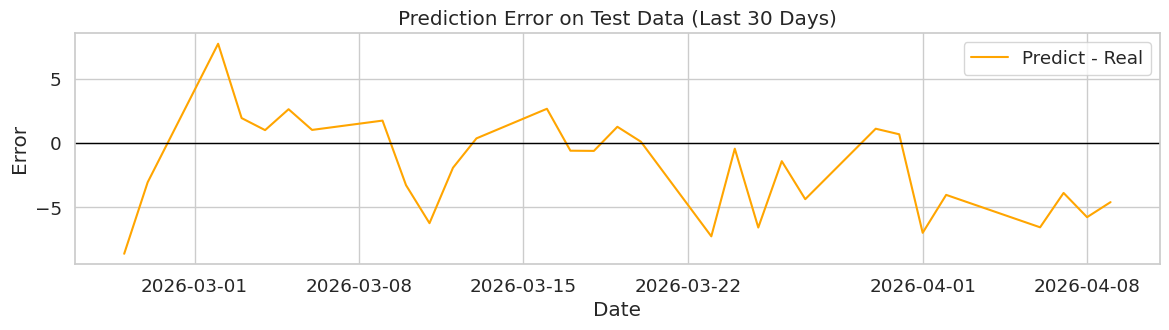

In [17]:
# Compare real vs predicted values on the same test time axis (last 30 days only)
model.eval()
with torch.no_grad():
    pred_scaled = model(X_test.to(device)).cpu().numpy().reshape(-1, 1)

real_scaled = y_test.cpu().numpy().reshape(-1, 1)

real_values = scaler.inverse_transform(real_scaled).reshape(-1)
pred_values = scaler.inverse_transform(pred_scaled).reshape(-1)

# Align date index to the same target points used by y_test
test_index = test_data.index[-len(real_values):]

comparison_df = pd.DataFrame({
    "Real_Value": real_values,
    "Predict_Value": pred_values
}, index=test_index)
comparison_df["Error"] = comparison_df["Predict_Value"] - comparison_df["Real_Value"]
comparison_df["Abs_Error"] = comparison_df["Error"].abs()

last_n_days = 30
comparison_recent = comparison_df.tail(last_n_days)

print(f"Real vs Predict on test period (last {last_n_days} days):")
display(comparison_recent)

plt.figure(figsize=(14, 4))
plt.plot(comparison_recent.index, comparison_recent["Real_Value"], label="Real Value", color="green")
plt.plot(comparison_recent.index, comparison_recent["Predict_Value"], label="Predict Value", color="red")
plt.title("Real vs Predict on Test Data (Last 30 Days)")
plt.xlabel("Date")
plt.ylabel("Open Price")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(14, 3))
plt.plot(comparison_recent.index, comparison_recent["Error"], label="Predict - Real", color="orange")
plt.axhline(0, color="black", linewidth=1)
plt.title("Prediction Error on Test Data (Last 30 Days)")
plt.xlabel("Date")
plt.ylabel("Error")
plt.grid(True)
plt.legend()
plt.show()